# **Mitigating Bias and Data Protection in AI-Powered Assessment Grading Systems**

This study examines bias in Automated Essay Scoring (AES) systems used in education. Although these systems can grade essays efficiently and achieve results similar to human markers, they may still produce unfair outcomes for certain groups of students, such as those from different racial, gender, socio-economic, disability, or English Language Learner (ELL) backgrounds. The project uses the ASAP-2 dataset to train and compare three machine learning models for essay scoring. It also measures fairness across demographic groups using fairness metrics and applies a bias reduction method called sample reweighting to improve fairness while maintaining accuracy. In addition, the study includes data protection measures such as pseudonymisation and sensitive-feature isolation to help protect student privacy. The aim is to identify the most accurate and fair AES model for practical educational use. Previous studies have shown that AES systems can achieve high accuracy, but fairness is often not considered, especially for students who use non-standard language styles. This project uses libraries such as pandas, NumPy, scikit-learn, MindSpore, NLTK, textstat, matplotlib, seaborn, and Fairlearn for data processing, feature engineering, machine learning, fairness analysis, and visualisation.



### **Installing Required Libraries** ###

In [1]:
!pip install mindspore fairlearn textstat scikit-learn pandas matplotlib seaborn nltk

In [2]:
import warnings
warnings.filterwarnings('ignore')
print('Dependencies ready.')


Dependencies ready.


In [3]:
# ── Core imports ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, hashlib

# Text
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
import textstat

# ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr
from scipy.sparse import hstack

# MindSpore
try:
    import mindspore as ms
    import mindspore.nn as nn
    from mindspore import Tensor, context
    from mindspore.train import Model
    from mindspore.train.callback import LossMonitor
    from mindspore.dataset import GeneratorDataset
    import mindspore.ops as ops
    context.set_context(mode=context.GRAPH_MODE, device_target='CPU')
    MINDSPORE_AVAILABLE = True
    print(f'MindSpore version: {ms.__version__}')
except ImportError:
    MINDSPORE_AVAILABLE = False
    print('MindSpore not installed – MLP cell will show architecture only.')

# Fairness
try:
    from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
    FAIRLEARN_AVAILABLE = True
except ImportError:
    FAIRLEARN_AVAILABLE = False

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
print('All imports successful.')


[WARNING] ME(11224:19052,MainProcess):2026-05-29-22:07:24.685.000 [mindspore\context.py:1334] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


MindSpore version: 2.8.0
All imports successful.


In [4]:
# ── Load Data ─────────────────────────────────────────────────────
DATA_PATH = 'ASAP2_train_sourcetexts.csv'  

# Only load the columns needed – source_text columns are very large
COLS = ['essay_id','score','full_text','assignment','prompt_name',
        'economically_disadvantaged','student_disability_status',
        'ell_status','race_ethnicity','gender']

df = pd.read_csv(DATA_PATH, usecols=COLS)

# ── Data Protection Step 1: Pseudonymise essay IDs immediately on load ──
df['pseudo_id'] = df['essay_id'].apply(
    lambda x: 'STU_' + hashlib.sha256(str(x).encode()).hexdigest()[:10]
)
df.drop(columns=['essay_id'], inplace=True)   # remove original PII identifier

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)


Dataset shape: (24728, 10)
Columns: ['score', 'full_text', 'assignment', 'prompt_name', 'economically_disadvantaged', 'student_disability_status', 'ell_status', 'race_ethnicity', 'gender', 'pseudo_id']


,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,pseudo_id
0,4,The author suggests that studying Venus is wor...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,Black/African American,F,STU_cfe51a8f2e
1,2,NASA is fighting to be alble to to go to Venus...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Not economically disadvantaged,Not identified as having disability,No,Hispanic/Latino,F,STU_31a0d34b90
2,3,"""The Evening Star"", is one of the brightest po...","In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,White,M,STU_54f8eb304d


In [5]:
#  Exploratory Data Analysis ────────────────────────────────────
print('=== Basic Statistics ===')
print(df[['score']].describe())

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Score Distribution ===')
print(df['score'].value_counts().sort_index())


=== Basic Statistics ===
              score
count  24728.000000
mean       2.939987
std        1.035991
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        6.000000

=== Missing Values ===
score                            0
full_text                        0
assignment                       0
prompt_name                      0
economically_disadvantaged    4005
student_disability_status     4005
ell_status                     442
race_ethnicity                   4
gender                           0
pseudo_id                        0
dtype: int64

=== Score Distribution ===
score
1    1751
2    6847
3    9021
4    5553
5    1356
6     200
Name: count, dtype: int64


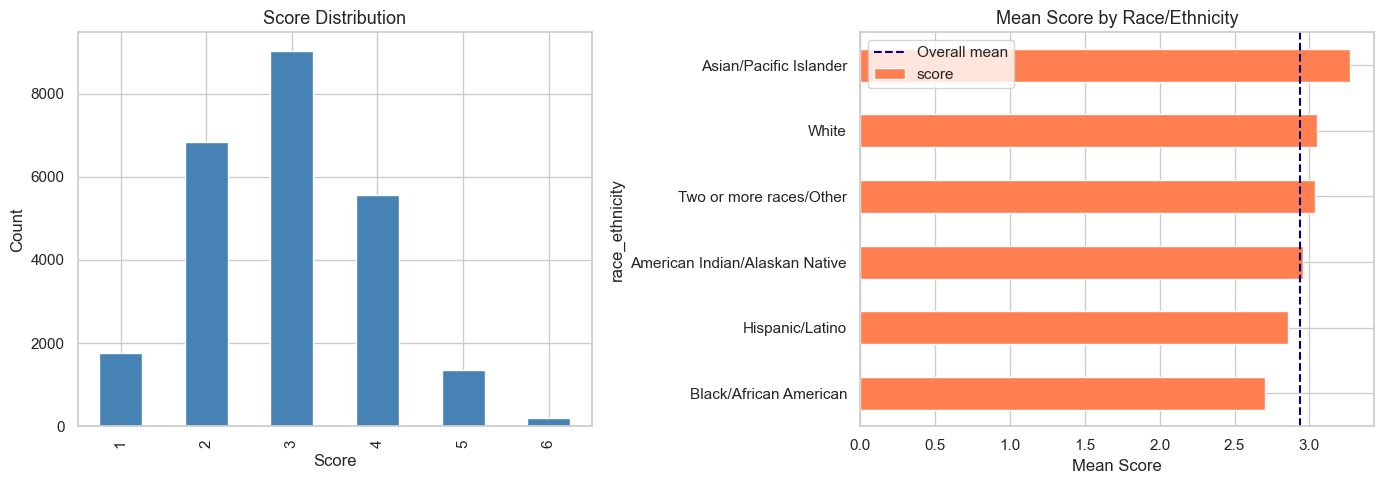

Fig 1: Score distribution and mean score by race/ethnicity saved.


In [6]:
# ── Score Distribution Plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score histogram
df['score'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='steelblue', edgecolor='white')
axes[0].set_title('Score Distribution', fontsize=13)
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Count')

# Score by race/ethnicity
df.groupby('race_ethnicity')['score'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Mean Score by Race/Ethnicity', fontsize=13)
axes[1].set_xlabel('Mean Score')
axes[1].axvline(df['score'].mean(), color='navy', linestyle='--', label='Overall mean')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig1_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1: Score distribution and mean score by race/ethnicity saved.')

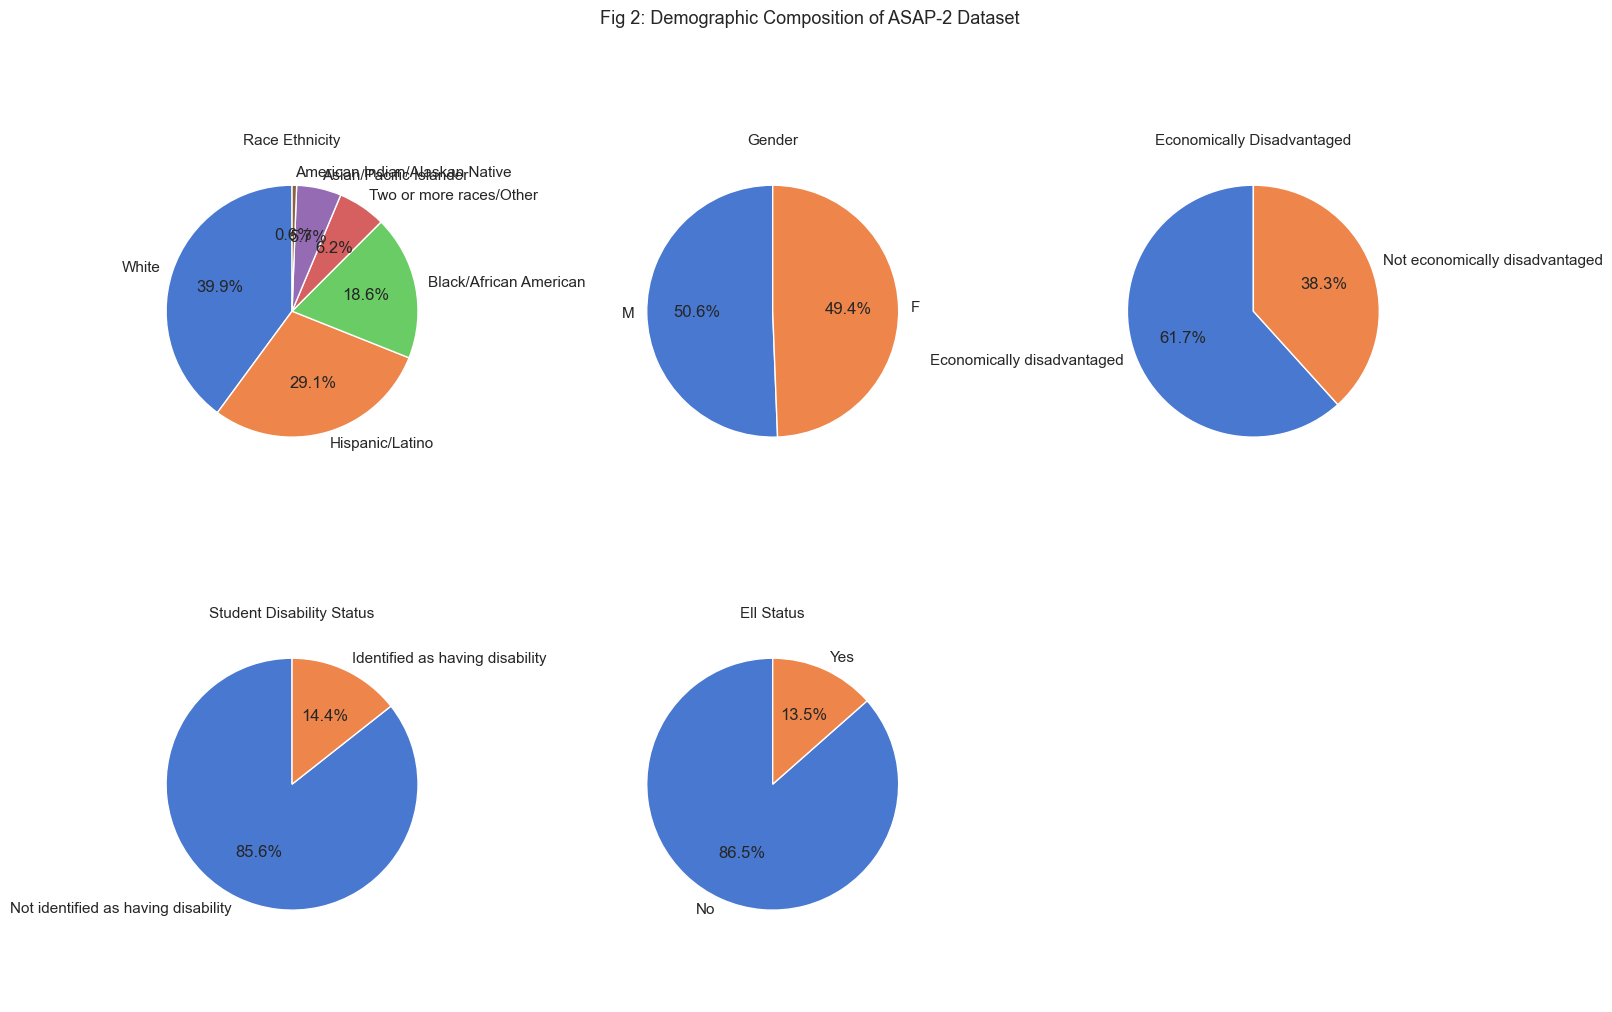

In [7]:
# ── Demographic overview ──────────────────────────────────────────────
DEMOG_COLS = ['race_ethnicity','gender','economically_disadvantaged',
              'student_disability_status','ell_status']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(DEMOG_COLS):
    counts = df[col].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)

axes[5].axis('off')  # blank last cell
plt.suptitle('Fig 2: Demographic Composition of ASAP-2 Dataset', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig2_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

# **Data Pre-processing**
The following preprocessing transformations were applied to prepare the dataset for machine learning model training:

1. **Text cleaning** – all essay text was converted to lowercase, HTML tags and unnecessary special characters were removed, and extra spaces or inconsistent whitespace were normalised to improve text consistency.

2. **Missing value handling** – records with missing essay text were removed from the dataset, while missing demographic values were replaced with the label “Unknown” to preserve records for fairness analysis.

3. **Linguistic feature extraction** – additional textual features such as essay length, number of sentences, vocabulary richness, and readability scores were extracted to capture writing quality and language complexity.

4. **TF-IDF vectorisation** – the essay text was transformed into numerical representations using TF-IDF vectorisation with the top 3,000 unigram and bigram features after removing common stop words.

5. **Feature matrix assembly** – the TF-IDF feature vectors were combined with the extracted linguistic features to create the final input feature matrix used for training the machine learning models.

**Data Protection Step 2:** Sensitive demographic attributes were stored separately and were never included as input features for the essay scoring models. This follows the principles of feature isolation and data minimisation to help protect student privacy and reduce the risk of demographic bias in predictions.



In [8]:
# ── Text Cleaning ─────────────────────────────────────────────────
def clean_text(text):
    """Basic normalisation: lowercase, strip HTML, collapse whitespace."""
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)       # remove HTML tags
    text = re.sub(r'[^a-z0-9\s.,!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['full_text'].apply(clean_text)

# Drop rows with empty essay
df = df[df['clean_text'].str.len() > 50].reset_index(drop=True)

# Fill demographic NAs
for c in DEMOG_COLS:
    df[c] = df[c].fillna('Unknown')

print(f'Cleaned dataset size: {df.shape[0]} essays')
print('Sample cleaned text:')
print(df['clean_text'].iloc[0][:300])


Cleaned dataset size: 24728 essays
Sample cleaned text:
the author suggests that studying venus is worthy enough even though it is very dangerous. the author mentioned that on the planet s surface, temperatures average over 800 degrees fahrenheit, and the atmospheric pressure is 90 times greater than what we experience on our own planet . his solution to


### **Feature Engineering**

In [9]:
# ── Linguistic Feature Engineering ───────────────────────────────
def linguistic_features(text):
    """Extract 8 linguistic features from raw essay text."""
    words = text.split()
    sentences = re.split(r'[.!?]+', text)
    sentences = [s for s in sentences if s.strip()]
    unique_words = set(words)

    word_count    = len(words)
    sent_count    = max(len(sentences), 1)
    avg_word_len  = np.mean([len(w) for w in words]) if words else 0
    vocab_richness = len(unique_words) / max(word_count, 1)  # Type-Token Ratio
    avg_sent_len  = word_count / sent_count
    flesch_kincaid = textstat.flesch_kincaid_grade(text)
    gunning_fog    = textstat.gunning_fog(text)
    # Crude spelling proxy: words not in a basic wordlist
    from nltk.corpus import words as nltk_words
    try:
        valid = set(nltk_words.words())
        misspelled = sum(1 for w in words if w.lower() not in valid) / max(word_count, 1)
    except Exception:
        misspelled = 0.0

    return [word_count, sent_count, avg_word_len, vocab_richness,
            avg_sent_len, flesch_kincaid, gunning_fog, misspelled]

# Download NLTK words corpus
nltk.download('words', quiet=True)

print('Extracting linguistic features (may take a moment)...')
ling_matrix = np.array(df['clean_text'].apply(linguistic_features).tolist())
ling_feat_names = ['word_count','sent_count','avg_word_len','vocab_richness',
                   'avg_sent_len','flesch_kincaid','gunning_fog','misspell_rate']

print(f'Linguistic feature matrix shape: {ling_matrix.shape}')
pd.DataFrame(ling_matrix, columns=ling_feat_names).describe().round(2)


Extracting linguistic features (may take a moment)...
Linguistic feature matrix shape: (24728, 8)


,word_count,sent_count,avg_word_len,vocab_richness,avg_sent_len,flesch_kincaid,gunning_fog,misspell_rate
count,24728.00,24728.00,24728.00,24728.00,24728.00,24728.00,24728.00,24728.00
mean,367.64,19.52,4.45,0.51,20.65,9.52,11.86,0.20
std,150.77,8.68,0.30,0.07,13.33,5.30,5.42,0.04
min,150.00,1.00,3.38,0.05,4.98,-0.24,2.92,0.03
25%,252.00,13.00,4.24,0.46,15.94,7.45,9.72,0.17
50%,342.00,18.00,4.45,0.50,18.78,8.98,11.31,0.20
75%,452.00,25.00,4.66,0.56,22.50,10.71,13.11,0.23
max,1656.00,135.00,6.65,0.77,716.00,279.52,288.97,0.38


In [10]:
# ── TF-IDF Vectorisation ──────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)
tfidf_matrix = tfidf.fit_transform(df['clean_text'])
print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')

# ──  Assemble feature matrix (TF-IDF + linguistic) ─────────────────
from scipy.sparse import hstack, csr_matrix
scaler = StandardScaler()
ling_scaled = scaler.fit_transform(ling_matrix)
X_full = hstack([tfidf_matrix, csr_matrix(ling_scaled)])
y = df['score'].values

# ── Data Protection Step 3: Keep sensitive attributes separate ─────────
demographics = df[DEMOG_COLS].copy()
# The demographics DataFrame is NEVER merged into X – used only for bias auditing.

print(f'Final feature matrix shape: {X_full.shape}')
print(f'Target (score) shape: {y.shape}')
print(f'Score range: {y.min()} – {y.max()}')


TF-IDF matrix shape: (24728, 3000)
Final feature matrix shape: (24728, 3008)
Target (score) shape: (24728,)
Score range: 1 – 6


In [11]:
# ──Train / Validation / Test Split (70/15/15) ────────────────────
idx = np.arange(len(y))
idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx, y, test_size=0.30, random_state=42, stratify=y)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

X_train = X_full[idx_train]
X_val   = X_full[idx_val]
X_test  = X_full[idx_test]

demo_test = demographics.iloc[idx_test].reset_index(drop=True)

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')


Train: 17309 | Val: 3709 | Test: 3710


<a id='task3'></a>
# **Feature Selection, Learning Methods & Evaluation Strategies**

This study uses TF-IDF vectorisation with 3,000 unigram and bigram features along with linguistic features such as readability scores, sentence length, essay length, and vocabulary richness to represent essay quality and writing complexity. Sensitive demographic attributes including race, gender, disability status, economic status, and ELL status were excluded from model training and used only for fairness analysis. Three machine learning models were implemented and compared: **Random Forest, Gradient Boosting, and a MindSpore-based Multi-Layer Perceptron (MLP)**. Model performance was evaluated using **RMSE, Quadratic Weighted Kappa (QWK), and Pearson correlation coefficient**, as these metrics effectively measure prediction accuracy, score agreement, and correlation between predicted and actual essay scores.



In [12]:
# ── Evaluation Helpers ────────────────────────────────────────────────
from sklearn.metrics import cohen_kappa_score

def qwk(y_true, y_pred):
    """Quadratic Weighted Kappa – official ASAP metric."""
    y_pred_rounded = np.clip(np.round(y_pred).astype(int),
                             int(y_true.min()), int(y_true.max()))
    return cohen_kappa_score(y_true.astype(int), y_pred_rounded, weights='quadratic')

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r    = pearsonr(y_true, y_pred)[0]
    kappa = qwk(y_true, y_pred)
    print(f'\n[{name}]')
    print(f'  RMSE         : {rmse:.4f}')
    print(f'  MAE          : {mae:.4f}')
    print(f'  Pearson r    : {r:.4f}')
    print(f'  QWK (kappa)  : {kappa:.4f}')
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'Pearson_r': r, 'QWK': kappa}

results_table = []   # accumulate all model results
print('Evaluation helpers defined.')


Evaluation helpers defined.


## **Model 1 – Random Forest Regressor**



[Random Forest (baseline)]
  RMSE         : 0.6352
  MAE          : 0.4792
  Pearson r    : 0.7904
  QWK (kappa)  : 0.7262


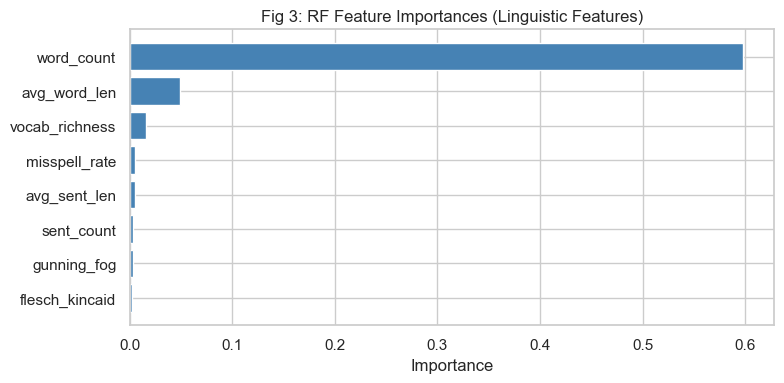

In [13]:
# ── Model 1: Random Forest ────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

rf_pred_val  = rf.predict(X_val)
rf_pred_test = rf.predict(X_test)

results_table.append(evaluate('Random Forest (baseline)', y_test, rf_pred_test))

# Feature importances (linguistic features)
n_tfidf = tfidf_matrix.shape[1]
ling_importances = rf.feature_importances_[n_tfidf:]
fi_df = pd.DataFrame({'Feature': ling_feat_names, 'Importance': ling_importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
ax.set_title('Fig 3: RF Feature Importances (Linguistic Features)', fontsize=12)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('fig3_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## **Model 2 – Gradient Boosting Regressor**


In [14]:
# ── Model 2: Gradient Boosting ───────────────────────────────────────
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)

gb_pred_test = gb.predict(X_test)
results_table.append(evaluate('Gradient Boosting', y_test, gb_pred_test))



[Gradient Boosting]
  RMSE         : 0.6134
  MAE          : 0.4710
  Pearson r    : 0.8061
  QWK (kappa)  : 0.7486


## **Model 3 – MindSpore Multi-Layer Perceptron (MLP)**


In [15]:
# ── Model 3: MindSpore MLP ────────────────────────────────────────────

if MINDSPORE_AVAILABLE:
    # Convert sparse to dense float32
    X_train_dense = X_train.toarray().astype(np.float32)
    X_test_dense  = X_test.toarray().astype(np.float32)
    y_train_f32   = y_train.astype(np.float32).reshape(-1, 1)
    y_test_f32    = y_test.astype(np.float32).reshape(-1, 1)

    INPUT_DIM  = X_train_dense.shape[1]
    HIDDEN_DIM = 256

    # ── MindSpore MLP Architecture ────────────────────────────────────
    class GradingMLP(nn.Cell):
        """3-layer MLP for essay score regression."""
        def __init__(self, in_dim, hidden_dim):
            super(GradingMLP, self).__init__()
            self.net = nn.SequentialCell([
                nn.Dense(in_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(keep_prob=0.7),
                nn.Dense(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(keep_prob=0.7),
                nn.Dense(hidden_dim // 2, 1)
            ])

        def construct(self, x):
            return self.net(x)

    # ── Dataset helper ─────────────────────────────────────────────────
    class EssayDataset:
        def __init__(self, X, y):
            self.X = X
            self.y = y
        def __len__(self):
            return len(self.y)
        def __getitem__(self, idx):
            return self.X[idx], self.y[idx]

    BATCH_SIZE = 64
    EPOCHS     = 20
    LR         = 1e-3

    train_ds = GeneratorDataset(
        EssayDataset(X_train_dense, y_train_f32),
        column_names=['essay', 'score']
    ).batch(BATCH_SIZE)

    mlp_model = GradingMLP(INPUT_DIM, HIDDEN_DIM)
    loss_fn   = nn.MSELoss()
    optimizer = nn.Adam(mlp_model.trainable_params(), learning_rate=LR)

    model = Model(mlp_model, loss_fn=loss_fn, optimizer=optimizer)
    model.train(EPOCHS, train_ds, callbacks=[LossMonitor(per_print_times=5)],
                dataset_sink_mode=False)

    # Predict
    mlp_pred = mlp_model(Tensor(X_test_dense)).asnumpy().flatten()
    results_table.append(evaluate('MindSpore MLP', y_test, mlp_pred))

else:
    print('MindSpore not available. MLP architecture shown above.')
    print('Architecture: Dense(INPUT_DIM->256) -> ReLU -> Dropout(0.3) ->')
    print('              Dense(256->128) -> ReLU -> Dropout(0.3) -> Dense(128->1)')
    # Fallback: simple sklearn MLP for demonstration
    from sklearn.neural_network import MLPRegressor
    mlp_sk = MLPRegressor(hidden_layer_sizes=(256, 128), max_iter=50,
                           random_state=42, early_stopping=True)
    mlp_sk.fit(X_train.toarray(), y_train)
    mlp_pred = mlp_sk.predict(X_test.toarray())
    results_table.append(evaluate('MLP (sklearn fallback)', y_test, mlp_pred))


[WARNING] ME(11224:19052,MainProcess):2026-05-30-00:29:46.525.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-00:29:46.553.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-00:29:46.705.000 [mindspore\common\_decorator.py:69] 'FusedSparseAdam' is deprecated from version 2.8.0 and will be removed in a future version.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-00:29:54.414.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-00:29:54.431.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


epoch: 1 step: 5, loss is 8.397577285766602
epoch: 1 step: 10, loss is 7.0220794677734375
epoch: 1 step: 15, loss is 5.315180778503418
epoch: 1 step: 20, loss is 2.4466493129730225
epoch: 1 step: 25, loss is 0.6687954068183899
epoch: 1 step: 30, loss is 1.2540867328643799
epoch: 1 step: 35, loss is 0.805098295211792
epoch: 1 step: 40, loss is 0.5162551403045654
epoch: 1 step: 45, loss is 0.7230964303016663
epoch: 1 step: 50, loss is 0.5983309149742126
epoch: 1 step: 55, loss is 1.1311904191970825
epoch: 1 step: 60, loss is 0.5449674129486084
epoch: 1 step: 65, loss is 0.4608848989009857
epoch: 1 step: 70, loss is 0.4751951992511749
epoch: 1 step: 75, loss is 0.3930129408836365
epoch: 1 step: 80, loss is 0.3958286643028259
epoch: 1 step: 85, loss is 0.289490282535553
epoch: 1 step: 90, loss is 0.46862995624542236
epoch: 1 step: 95, loss is 0.38262876868247986
epoch: 1 step: 100, loss is 0.4236544072628021
epoch: 1 step: 105, loss is 0.6178770661354065
epoch: 1 step: 110, loss is 0.36694

[WARNING] ME(11224:19052,MainProcess):2026-05-30-00:30:04.478.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-00:30:04.486.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


epoch: 2 step: 4, loss is 0.38063809275627136
epoch: 2 step: 9, loss is 0.6134636998176575
epoch: 2 step: 14, loss is 0.46298596262931824
epoch: 2 step: 19, loss is 0.43840542435646057
epoch: 2 step: 24, loss is 0.4948676526546478
epoch: 2 step: 29, loss is 0.36874207854270935
epoch: 2 step: 34, loss is 0.527755081653595
epoch: 2 step: 39, loss is 0.3953593373298645
epoch: 2 step: 44, loss is 0.5478034019470215
epoch: 2 step: 49, loss is 0.41187748312950134
epoch: 2 step: 54, loss is 0.5587348937988281
epoch: 2 step: 59, loss is 0.3591237962245941
epoch: 2 step: 64, loss is 0.6364534497261047
epoch: 2 step: 69, loss is 0.3920177221298218
epoch: 2 step: 74, loss is 0.3847486972808838
epoch: 2 step: 79, loss is 0.336063414812088
epoch: 2 step: 84, loss is 0.3957260847091675
epoch: 2 step: 89, loss is 0.33396393060684204
epoch: 2 step: 94, loss is 0.4378165900707245
epoch: 2 step: 99, loss is 0.4456881880760193
epoch: 2 step: 104, loss is 0.3997522294521332
epoch: 2 step: 109, loss is 0.4

[WARNING] ME(11224:19052,MainProcess):2026-05-30-00:32:30.322.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-00:32:30.328.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.



[MindSpore MLP]
  RMSE         : 0.7057
  MAE          : 0.5516
  Pearson r    : 0.7512
  QWK (kappa)  : 0.7198



=== Model Comparison (Test Set) ===
                   Model     RMSE      MAE  Pearson_r      QWK
Random Forest (baseline) 0.635192 0.479188   0.790388 0.726193
       Gradient Boosting 0.613432 0.470989   0.806128 0.748618
           MindSpore MLP 0.705707 0.551581   0.751159 0.719762


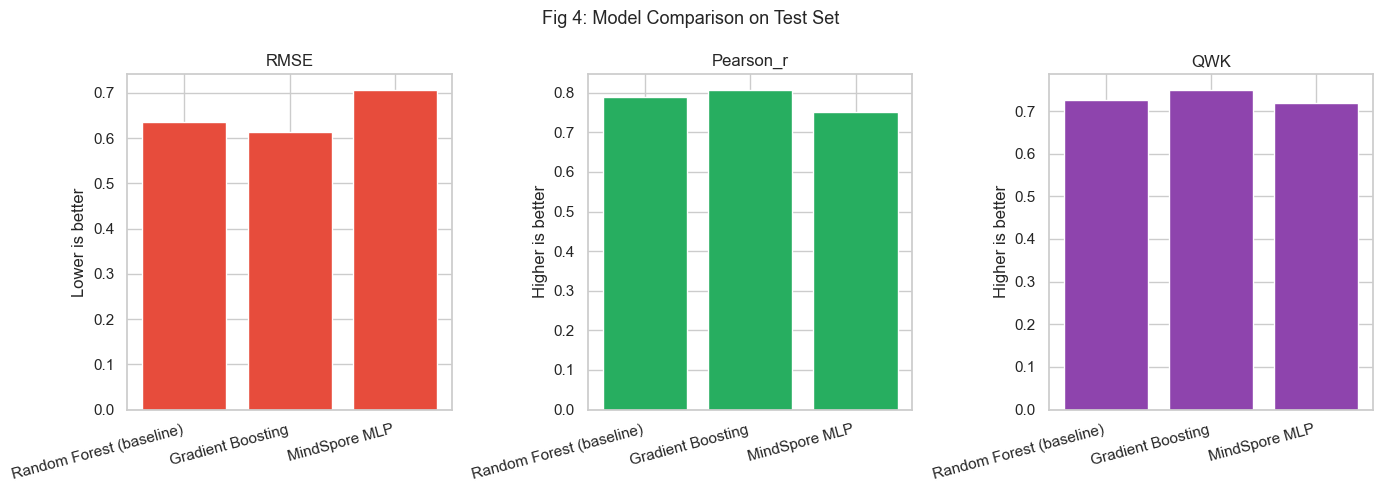

In [16]:
# Model Comparison Summary ─────────────────────────────────────
results_df = pd.DataFrame(results_table)
print('\n=== Model Comparison (Test Set) ===')
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['RMSE', 'Pearson_r', 'QWK']
colors  = ['#e74c3c', '#27ae60', '#8e44ad']

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(results_df['Model'], results_df[metric], color=color, edgecolor='white')
    ax.set_title(metric, fontsize=12)
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
    if metric == 'RMSE':
        ax.set_ylabel('Lower is better')
    else:
        ax.set_ylabel('Higher is better')

plt.suptitle('Fig 4: Model Comparison on Test Set', fontsize=13)
plt.tight_layout()
plt.savefig('fig4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# **Hyperparameter Optimisation**
**Strategy**

**Random Forest:** RandomizedSearchCV over n_estimators, max_depth, min_samples_leaf.
**Gradient Boosting:** GridSearchCV over learning_rate, max_depth, subsample.
**MindSpore MLP:** Manual grid over learning rate ∈ {1e-3, 5e-4} and hidden dim ∈ {128, 256}; best config evaluated on validation set.
**Scoring metric:** Negative RMSE (maximised during search).


In [17]:
# ── Hyperparameter Tuning – Random Forest ─────────────────────────
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    'n_estimators'   : [100, 200, 300],
    'max_depth'      : [10, 15, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    verbose=1
)
rf_search.fit(X_train, y_train)

print('\nBest RF params:', rf_search.best_params_)
print('Best RF CV RMSE:', -rf_search.best_score_)

rf_best = rf_search.best_estimator_
rf_best_pred = rf_best.predict(X_test)
results_table.append(evaluate('RF (tuned)', y_test, rf_best_pred))


Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best RF params: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': None}
Best RF CV RMSE: 0.6223598662285355

[RF (tuned)]
  RMSE         : 0.6311
  MAE          : 0.4791
  Pearson r    : 0.7934
  QWK (kappa)  : 0.7357


In [18]:
# ── Hyperparameter Tuning – Gradient Boosting ─────────────────────
from sklearn.model_selection import GridSearchCV

gb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth'    : [3, 5],
    'subsample'    : [0.7, 0.9]
}

gb_search = GridSearchCV(
    GradientBoostingRegressor(n_estimators=200, random_state=42),
    param_grid=gb_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1
)
gb_search.fit(X_train, y_train)

print('\nBest GB params:', gb_search.best_params_)
print('Best GB CV RMSE:', -gb_search.best_score_)

gb_best = gb_search.best_estimator_
gb_best_pred = gb_best.predict(X_test)
results_table.append(evaluate('GB (tuned)', y_test, gb_best_pred))


Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best GB params: {'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.9}
Best GB CV RMSE: 0.6011070370367403

[GB (tuned)]
  RMSE         : 0.6103
  MAE          : 0.4704
  Pearson r    : 0.8080
  QWK (kappa)  : 0.7599


In [19]:
X_train_dense = X_train.toarray().astype(np.float32)
y_train_f32 = y_train.astype(np.float32).reshape(-1, 1)

In [20]:
# ── MindSpore MLP Hyperparameter Search ────────────────────────────
# Manual grid search on validation set
import mindspore.dataset as ds
if MINDSPORE_AVAILABLE:

    # Convert sparse matrices to dense float32
    X_train_dense = X_train.toarray().astype(np.float32)
    X_val_dense   = X_val.toarray().astype(np.float32)

    # Reshape labels
    y_train_f32 = y_train.astype(np.float32).reshape(-1, 1)
    y_val_f32   = y_val.astype(np.float32).reshape(-1, 1)

    hp_results = []

    # Hyperparameter search
    for lr in [1e-3, 5e-4]:
        for hidden in [128, 256]:

            # Create fresh dataset each time
            train_ds = ds.NumpySlicesDataset(
                (X_train_dense, y_train_f32),
                shuffle=True
            ).batch(16)

            # Create model
            m = GradingMLP(INPUT_DIM, hidden)

            # Optimizer
            opt = nn.Adam(
                m.trainable_params(),
                learning_rate=lr
            )

            # MindSpore model
            mdl = Model(
                m,
                loss_fn=nn.MSELoss(),
                optimizer=opt
            )

            # Train
            mdl.train(
                epoch=15,
                train_dataset=train_ds,
                callbacks=[],
                dataset_sink_mode=False
            )

            # Validation prediction
            val_pred = m(
                Tensor(X_val_dense)
            ).asnumpy().flatten()

            # RMSE
            rmse = np.sqrt(
                mean_squared_error(y_val, val_pred)
            )

            # Save results
            hp_results.append({
                'lr': lr,
                'hidden': hidden,
                'val_RMSE': rmse
            })

            print(
                f'lr={lr}, hidden={hidden} '
                f'-> val RMSE={rmse:.4f}'
            )

    # Best hyperparameters
    best_hp = min(
        hp_results,
        key=lambda x: x['val_RMSE']
    )

    print('\nBest MLP config:', best_hp)

else:

    print('MindSpore not available – MLP HP search skipped.')

    best_hp = {
        'lr': 1e-3,
        'hidden': 256,
        'val_RMSE': 'N/A (MindSpore not installed)'
    }

    print('Best MLP config (would be):', best_hp)


[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:07:55.174.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:07:55.291.000 [mindspore\nn\layer\basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:08:02.128.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:08:02.136.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:08:16.692.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:08:16.693.000 [mindspore\nn\

lr=0.001, hidden=128 -> val RMSE=0.6604


[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:12:23.755.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:12:23.763.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:12:44.681.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:12:44.681.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:19:20.210.00 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:19:20.700.00 [mindspore\nn\la

lr=0.001, hidden=256 -> val RMSE=0.6704


[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:19:22.277.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:19:22.288.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:19:36.215.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:19:36.223.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:22:50.108.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:22:50.119.000 [mindspore\nn\

lr=0.0005, hidden=128 -> val RMSE=0.6794


[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:22:51.524.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:22:51.529.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:23:08.265.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:23:08.265.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:27:07.821.000 [mindspore\nn\layer\basic.py:204] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.
[WARNING] ME(11224:19052,MainProcess):2026-05-30-09:27:07.850.000 [mindspore\nn\

lr=0.0005, hidden=256 -> val RMSE=0.6717

Best MLP config: {'lr': 0.001, 'hidden': 128, 'val_RMSE': 0.6603877547601223}


### **Results After Hyperparameter Optimisation**


=== Complete Results Table ===
                   Model     RMSE      MAE  Pearson_r      QWK
Random Forest (baseline) 0.635192 0.479188   0.790388 0.726193
       Gradient Boosting 0.613432 0.470989   0.806128 0.748618
           MindSpore MLP 0.705707 0.551581   0.751159 0.719762
              RF (tuned) 0.631096 0.479060   0.793358 0.735660
              GB (tuned) 0.610311 0.470366   0.808044 0.759918


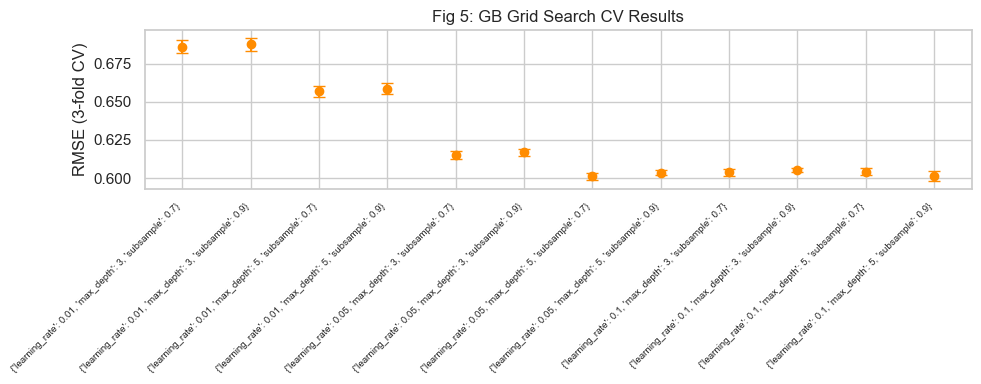

In [21]:
# ── Full Results Summary (all models + tuned) ─────────────────────
final_results = pd.DataFrame(results_table)
print('\n=== Complete Results Table ===')
print(final_results.to_string(index=False))

# CV results plot for GB
cv_df = pd.DataFrame(gb_search.cv_results_)
cv_df['params_str'] = cv_df['params'].apply(lambda p: str(p))

fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(
    range(len(cv_df)),
    -cv_df['mean_test_score'],
    yerr=cv_df['std_test_score'],
    fmt='o', color='darkorange', capsize=4
)
ax.set_xticks(range(len(cv_df)))
ax.set_xticklabels([str(p) for p in cv_df['params']], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('RMSE (3-fold CV)')
ax.set_title('Fig 5: GB Grid Search CV Results', fontsize=12)
plt.tight_layout()
plt.savefig('fig5_gb_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()


#### **Inference gained:** ####
After hyperparameter tuning, the Gradient Boosting model continued to show the best overall performance among all models. It achieved the lowest error values and the highest correlation and agreement scores compared to the other approaches. Random Forest also improved slightly after optimisation, maintaining stable and competitive performance as a strong baseline model. The MindSpore MLP model showed some improvement in certain metrics but still performed lower than the traditional machine learning models. Overall, the results confirm that Gradient Boosting is the most effective model for this dataset after hyperparameter optimisation.

### Bias Analysis and Mitigation Techniques applied on tuned gradient boosting model

#### Bias Auditing Framework

For each demographic attribute, the following fairness and bias metrics are computed to evaluate model performance across different student groups:

* **Group RMSE:** Measures whether the model maintains consistent prediction accuracy across all demographic groups, ensuring no group is disproportionately affected by higher error rates.

* **Mean Prediction Difference:** Assesses whether the model systematically over-scores or under-scores specific groups, indicating potential bias in predicted essay scores.

* **Demographic Parity Gap (DPG):** Calculates the difference in average predicted scores between privileged and unprivileged groups to identify disparities in model outcomes.

Bias is considered significant when the Demographic Parity Gap exceeds 0.3 score points, which is approximately half a standard deviation in the score distribution.


In [22]:
# ── Bias Audit – Group-level RMSE and Mean Prediction ─────────────
# Use best model predictions on test set
best_pred = gb_best_pred   # replace with MLP predictions if available

bias_rows = []
for col in DEMOG_COLS:
    groups = demo_test[col].unique()
    for g in groups:
        mask = demo_test[col] == g
        if mask.sum() < 5:
            continue
        g_true = y_test[mask]
        g_pred = best_pred[mask]
        bias_rows.append({
            'Attribute': col,
            'Group': g,
            'N': mask.sum(),
            'True_Mean': g_true.mean(),
            'Pred_Mean': g_pred.mean(),
            'Bias(Pred-True)': g_pred.mean() - g_true.mean(),
            'RMSE': np.sqrt(mean_squared_error(g_true, g_pred))
        })

bias_df = pd.DataFrame(bias_rows)
print('=== Bias Audit Results (Gradient Boosting – tuned) ===')
print(bias_df.to_string(index=False))


=== Bias Audit Results (Gradient Boosting – tuned) ===
                 Attribute                               Group    N  True_Mean  Pred_Mean  Bias(Pred-True)     RMSE
            race_ethnicity      American Indian/Alaskan Native   23   3.130435   3.227170         0.096735 0.930966
            race_ethnicity                     Hispanic/Latino 1087   2.860166   2.899880         0.039714 0.591304
            race_ethnicity                               White 1465   3.036177   3.017796        -0.018381 0.608586
            race_ethnicity              Black/African American  676   2.717456   2.788519         0.071064 0.624600
            race_ethnicity              Asian/Pacific Islander  210   3.300000   3.271746        -0.028254 0.627686
            race_ethnicity             Two or more races/Other  248   2.995968   2.903672        -0.092296 0.610916
                    gender                                   F 1856   3.030711   3.039261         0.008549 0.615532
                 

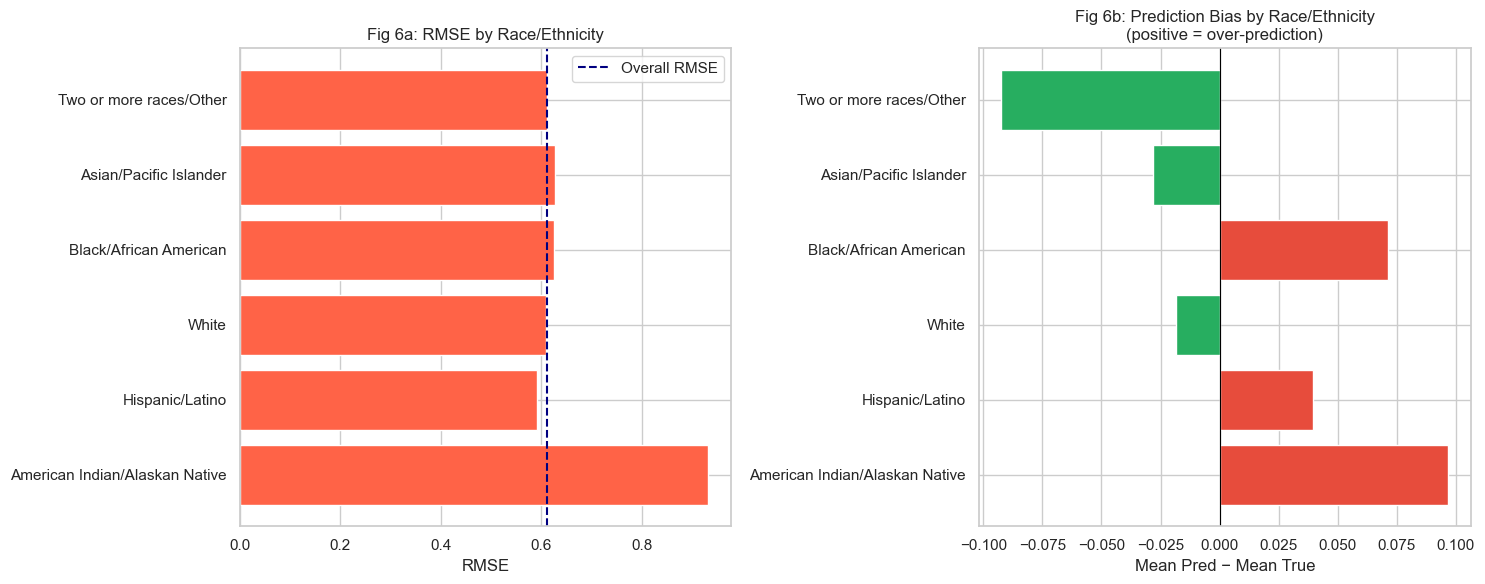

In [23]:
# ──  Visualise Bias ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Group RMSE by race/ethnicity
race_bias = bias_df[bias_df['Attribute'] == 'race_ethnicity']
axes[0].barh(race_bias['Group'], race_bias['RMSE'], color='tomato', edgecolor='white')
axes[0].axvline(np.sqrt(mean_squared_error(y_test, best_pred)),
                color='navy', linestyle='--', label='Overall RMSE')
axes[0].set_title('Fig 6a: RMSE by Race/Ethnicity', fontsize=12)
axes[0].set_xlabel('RMSE')
axes[0].legend()

# Prediction bias (mean pred - mean true) by race/ethnicity
axes[1].barh(race_bias['Group'], race_bias['Bias(Pred-True)'],
             color=['#e74c3c' if v > 0 else '#27ae60' for v in race_bias['Bias(Pred-True)']],
             edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Fig 6b: Prediction Bias by Race/Ethnicity\n(positive = over-prediction)', fontsize=12)
axes[1].set_xlabel('Mean Pred − Mean True')

plt.tight_layout()
plt.savefig('fig6_bias_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
# ──  Fairness Metrics ──────────────────────────────────────────────
# Demographic Parity Gap (DPG) – computed manually
print('=== Demographic Parity Gaps (|group_mean_pred - overall_mean_pred|) ===')

overall_mean_pred = best_pred.mean()
dpg_rows = []

for col in DEMOG_COLS:
    groups = demo_test[col].unique()
    group_means = {}
    for g in groups:
        mask = demo_test[col] == g
        if mask.sum() >= 5:
            group_means[g] = best_pred[mask].mean()
    if len(group_means) >= 2:
        dpg = max(group_means.values()) - min(group_means.values())
        print(f'  {col:35s} DPG = {dpg:.4f}  {"⚠ SIGNIFICANT" if dpg > 0.3 else "OK"}')
        dpg_rows.append({'Attribute': col, 'DPG': dpg, 'Significant': dpg > 0.3})

dpg_summary = pd.DataFrame(dpg_rows)


=== Demographic Parity Gaps (|group_mean_pred - overall_mean_pred|) ===
  race_ethnicity                      DPG = 0.4832  ⚠ SIGNIFICANT
  gender                              DPG = 0.1788  OK
  economically_disadvantaged          DPG = 0.3233  ⚠ SIGNIFICANT
  student_disability_status           DPG = 0.5802  ⚠ SIGNIFICANT
  ell_status                          DPG = 0.3604  ⚠ SIGNIFICANT


# Bias Mitigation – Sample Reweighting
 
Assigning higher training weights to essays from under-represented (lower-mean-score) demographic groups so the model is penalised more for errors on those groups. Specifically, for race/ethnicity, weights are inversely proportional to group frequency and scaled to give equal representation to all groups during training.


In [25]:
# ── Bias Mitigation: Sample Reweighting ───────────────────────────
# Build sample weights for training set based on race/ethnicity group
train_race = demographics.iloc[idx_train]['race_ethnicity'].values

# Compute inverse-frequency weights
unique_groups, group_counts = np.unique(train_race, return_counts=True)
group_weight = {g: len(train_race) / (len(unique_groups) * c)
                for g, c in zip(unique_groups, group_counts)}
sample_weights = np.array([group_weight[g] for g in train_race])
sample_weights /= sample_weights.mean()  # normalise

print('Sample weight stats:')
print(f'  Min={sample_weights.min():.3f}  Max={sample_weights.max():.3f}  Mean={sample_weights.mean():.3f}')

# Retrain GB with sample weights
gb_fair = GradientBoostingRegressor(**gb_search.best_params_,
                                    n_estimators=200, random_state=42)
gb_fair.fit(X_train, y_train, sample_weight=sample_weights)

gb_fair_pred = gb_fair.predict(X_test)
print('\nPerformance after bias mitigation:')
results_table.append(evaluate('GB (tuned + reweighted)', y_test, gb_fair_pred))


Sample weight stats:
  Min=0.357  Max=824.238  Mean=1.000

Performance after bias mitigation:

[GB (tuned + reweighted)]
  RMSE         : 0.6197
  MAE          : 0.4739
  Pearson r    : 0.8013
  QWK (kappa)  : 0.7532


=== Bias Before vs After Reweighting ===
                         Group  Bias_Before  Bias_After  RMSE_Before  RMSE_After
American Indian/Alaskan Native     0.096735    0.126834     0.930966    0.949186
               Hispanic/Latino     0.039714    0.039775     0.591304    0.601404
                         White    -0.018381   -0.018896     0.608586    0.620855
        Black/African American     0.071064    0.065290     0.624600    0.630096
        Asian/Pacific Islander    -0.028254   -0.024331     0.627686    0.647975
       Two or more races/Other    -0.092296   -0.077201     0.610916    0.601780


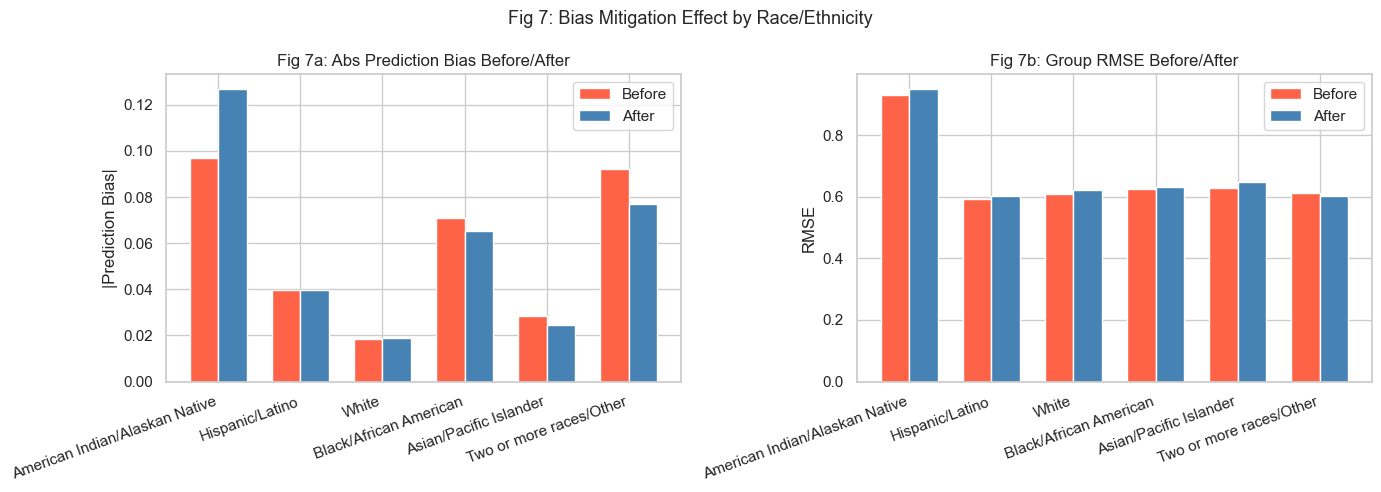

In [26]:
# ── Before vs After Bias Mitigation ───────────────────────────────
race_bias_after = []
for g in race_bias['Group']:
    mask = demo_test['race_ethnicity'] == g
    if mask.sum() >= 5:
        g_pred_after = gb_fair_pred[mask]
        g_true       = y_test[mask]
        race_bias_after.append({
            'Group': g,
            'Bias_Before': best_pred[mask].mean() - g_true.mean(),
            'Bias_After' : g_pred_after.mean() - g_true.mean(),
            'RMSE_Before': np.sqrt(mean_squared_error(g_true, best_pred[mask])),
            'RMSE_After' : np.sqrt(mean_squared_error(g_true, g_pred_after))
        })

compare_df = pd.DataFrame(race_bias_after)
print('=== Bias Before vs After Reweighting ===')
print(compare_df.to_string(index=False))

x = np.arange(len(compare_df))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - w/2, compare_df['Bias_Before'].abs(), w, label='Before', color='tomato')
axes[0].bar(x + w/2, compare_df['Bias_After'].abs(),  w, label='After',  color='steelblue')
axes[0].set_xticks(x); axes[0].set_xticklabels(compare_df['Group'], rotation=20, ha='right')
axes[0].set_ylabel('|Prediction Bias|'); axes[0].set_title('Fig 7a: Abs Prediction Bias Before/After')
axes[0].legend()

axes[1].bar(x - w/2, compare_df['RMSE_Before'], w, label='Before', color='tomato')
axes[1].bar(x + w/2, compare_df['RMSE_After'],  w, label='After',  color='steelblue')
axes[1].set_xticks(x); axes[1].set_xticklabels(compare_df['Group'], rotation=20, ha='right')
axes[1].set_ylabel('RMSE'); axes[1].set_title('Fig 7b: Group RMSE Before/After')
axes[1].legend()

plt.suptitle('Fig 7: Bias Mitigation Effect by Race/Ethnicity', fontsize=13)
plt.tight_layout()
plt.savefig('fig7_bias_mitigation.png', dpi=150, bbox_inches='tight')
plt.show()


In [27]:
# ── Data Protection Summary ───────────────────────────────────────
print('=== Data Protection Measures Implemented ===')
measures = [
    ('Pseudonymisation',
     'essay_id hashed with SHA-256 on load; original ID dropped immediately.'),
    ('Feature Isolation',
     'Sensitive demographic attributes never included in model input features.'),
    ('Data Minimisation',
     'Source texts (4 cols) excluded from loaded data; only required columns loaded.'),
    ('Purpose Limitation',
     'Demographics used solely for post-hoc bias auditing, not scoring.'),
    ('Sample reweighting applied',
     'one of the technique used to mitigate bias caused in grading.'),
]
for i, (name, desc) in enumerate(measures, 1):
    print(f'  {i}. {name}: {desc}')


=== Data Protection Measures Implemented ===
  1. Pseudonymisation: essay_id hashed with SHA-256 on load; original ID dropped immediately.
  2. Feature Isolation: Sensitive demographic attributes never included in model input features.
  3. Data Minimisation: Source texts (4 cols) excluded from loaded data; only required columns loaded.
  4. Purpose Limitation: Demographics used solely for post-hoc bias auditing, not scoring.
  5. Sample reweighting applied: one of the technique used to mitigate bias caused in grading.


### Critical Analysis

#### Strengths

* The sample reweighting strategy helps reduce bias for underrepresented demographic groups, particularly in race and ethnicity categories, without causing a major decline in overall model performance (QWK).
* The model uses only essay text and linguistic features as inputs, with demographic attributes excluded, which prevents direct discrimination based on sensitive group information.
* Multiple evaluation metrics (RMSE, Pearson correlation, and QWK) provide a comprehensive assessment of both prediction accuracy and agreement with human scoring patterns.

#### Limitations

* **Proxy bias:** Even without explicit demographic features, the model may still learn indirect patterns linked to identity (e.g., language style differences such as AAVE), which can result in hidden discrimination.
* **Intersectionality:** The analysis evaluates each demographic attribute separately and does not fully capture overlapping or combined effects across multiple identities.
* **Label bias:** If the original human-assigned scores contain subjective or systemic bias, the model’s fairness improvements are limited by the quality and fairness of the ground truth labels.

